<a href="https://colab.research.google.com/github/rasikacs23172/mechine-learning-tae/blob/main/Model_3_logisticregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')

Mounted at /content/drive
Google Drive mounted successfully.


In [20]:
import pandas as pd
df = pd.read_csv('/content/student-mat (1).csv', delimiter=';')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [21]:
from sklearn.model_selection import train_test_split

# 1. Create the target variable 'y'
y = (df['G3'] >= 10).astype(int)

# 2. Create the feature matrix 'X' by dropping grade-related columns
X = df.drop(['G1', 'G2', 'G3'], axis=1)

# 3. Apply one-hot encoding to all categorical columns in X
X = pd.get_dummies(X, drop_first=True)

# 4. and 5. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data preparation complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data preparation complete.
Shape of X_train: (276, 39)
Shape of X_test: (119, 39)
Shape of y_train: (276,)
Shape of y_test: (119,)


In [22]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [23]:
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

print("Predictions made successfully using the Logistic Regression model.")

Predictions made successfully using the Logistic Regression model.


In [24]:
print("First 10 Predicted Class Labels (Logistic Regression):")
print(y_pred_log_reg[:10])

print("\nFirst 10 Predicted Probabilities for Positive Class (Logistic Regression):")
print(y_pred_proba_log_reg[:10])

First 10 Predicted Class Labels (Logistic Regression):
[0 1 0 1 0 1 1 1 1 1]

First 10 Predicted Probabilities for Positive Class (Logistic Regression):
[0.12955546 0.51555038 0.35068176 0.80374922 0.42714519 0.82854219
 0.82660703 0.81425678 0.87032909 0.864793  ]


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_log_reg)

# Calculate precision
precision = precision_score(y_test, y_pred_log_reg)

# Calculate recall
recall = recall_score(y_test, y_pred_log_reg)

# Calculate F1-score
f1 = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.7143
Precision: 0.7053
Recall: 0.9178
F1-score: 0.7976


In [26]:
from sklearn.metrics import roc_auc_score

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba_log_reg)

print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7370


In [28]:
from sklearn.metrics import roc_curve

# Calculate FPR, TPR, and thresholds for Logistic Regression
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_test, y_pred_proba_log_reg)

print("First 5 FPR values (Logistic Regression):")
print(fpr_log_reg[:5])
print("\nFirst 5 TPR values (Logistic Regression):")
print(tpr_log_reg[:5])
print("\nFirst 5 Thresholds values (Logistic Regression):")
print(thresholds_log_reg[:5])

First 5 FPR values (Logistic Regression):
[0.         0.         0.         0.02173913 0.02173913]

First 5 TPR values (Logistic Regression):
[0.         0.01369863 0.16438356 0.16438356 0.2739726 ]

First 5 Thresholds values (Logistic Regression):
[       inf 0.98630737 0.9367983  0.93603154 0.91856362]


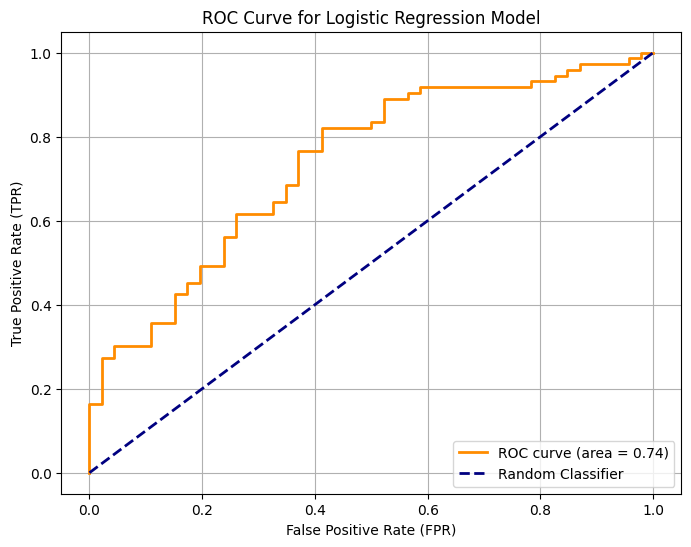

In [29]:
import matplotlib.pyplot as plt

# Create a new figure and an axes object
plt.figure(figsize=(8, 6))

# Plot the ROC curve
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')

# Plot a diagonal dashed line for a random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Set the title and labels
plt.title('ROC Curve for Logistic Regression Model')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()